# Customer Usage Clustering – Combined Unsupervised Learning Notebook

## Problem Statements

### 1. K-Means Clustering
**Can we divide customers into groups based on their usage patterns?**

### 2. Hierarchical Clustering
**Can we discover how customers are related based on their usage patterns?**

### 3. DBSCAN
**Can we identify unusual customers based on their service usage?**

---

## Objective

This notebook uses the **same customer churn dataset** and implements the three clustering techniques **separately**.

The workflow includes:

**Raw Dataset → Problem Understanding → Data Understanding → Data Cleaning → EDA → Outlier Detection/Handling → Remove Unnecessary Columns → Feature Selection → Encoding → Feature Scaling → Final Validation → Model-Specific Clustering → Evaluation → Cluster Profiling → Business Interpretation → PCA Visualization → Conclusion**

> **Important:** `Churn` is treated as a target/label and is not used for clustering. `Customer_ID` is treated as an identifier and is not used as a feature.

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# 2. Load the Raw Dataset

The same dataset is used for all three models.

In [2]:
file_path = r"C:\Users\hp\Desktop\calibo\Supervised_Learning_Messy_Customer_Churn.csv"

df_raw = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)
display(df_raw.head())

Dataset loaded successfully.
Shape: (184, 13)


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


# 3. Initial Data Understanding

Check:
- Shape
- Column names
- Data types
- Statistical summary
- First and last records

In [3]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nDataset information:")
df_raw.info()

print("\nStatistical summary:")
display(df_raw.describe(include="all").T)

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nLast 5 rows:")
display(df_raw.tail())

Rows: 184
Columns: 13

Column names:
['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']

Data types:
Customer_ID                  str
Age                      float64
Annual_Income                str
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
Churn                        str
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    str    
 1   Age                    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,184,180,CUST-1043,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,176.0,NaN,NaN,NaN,36.164773,12.865951,-5.0,29.0,36.0,41.0,145.0
Annual_Income,173,156,76600.0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure_Months,177.0,NaN,NaN,NaN,39.39548,21.545185,1.0,25.0,38.0,55.0,150.0
Monthly_Charges,178.0,NaN,NaN,NaN,80.205899,74.17937,0.0,57.885,73.565,90.28,999.0
Support_Calls_Last_3M,179.0,NaN,NaN,NaN,3.217877,2.577455,0.0,2.0,3.0,4.0,30.0
Data_Usage_GB,178.0,NaN,NaN,NaN,17.80618,9.245516,-10.0,11.6,18.2,24.2,44.0
Satisfaction_Score,178.0,NaN,NaN,NaN,5.803371,2.947869,1.0,4.0,6.0,8.0,15.0
Contract_Type,184,8,Monthly,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Method,184,9,Bank Transfer,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN



First 5 rows:


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes



Last 5 rows:


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
179,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1 Year,Bank Transfer,East,Basic,Yes
180,CUST-1015,19.0,63000.0,NaN,64.24,1.0,13.0,7.0,Monthly,Credit Card,south,Premium,Yes
181,CUST-1093,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,Monthly,Debit Card,East,Standard,No
182,CUST-1180,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,Monthly,UPI,East,Standard,Yes
183,CUST-1103,NaN,48300.0,13.0,94.69,0.0,16.8,1.0,2 Year,Bank Transfer,West,Standard,No


# 4. Convert `Annual_Income` to Numeric

The dataset may contain commas, dollar signs, or text values in `Annual_Income`. Convert it safely before numerical analysis.

In [4]:
df = df_raw.copy()

if "Annual_Income" in df.columns:
    df["Annual_Income"] = (
        df["Annual_Income"]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )
    df["Annual_Income"] = pd.to_numeric(
        df["Annual_Income"],
        errors="coerce"
    )

print("Annual_Income data type:")
if "Annual_Income" in df.columns:
    print(df["Annual_Income"].dtype)
else:
    print("Annual_Income column not found.")

Annual_Income data type:
Float64


# 5. Check Missing Values

In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values[missing_values > 0])

print("Total missing values:", int(missing_values.sum()))

Missing values in each column:


Age                       8
Annual_Income            12
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
dtype: int64

Total missing values: 50


# 6. Check and Remove Duplicate Records

In [6]:
duplicate_count = int(df.duplicated().sum())

print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 4
Shape after removing duplicates: (180, 13)


# 7. Exploratory Data Analysis – Correlation Heatmap

The heatmap shows relationships between numerical customer features before clustering.

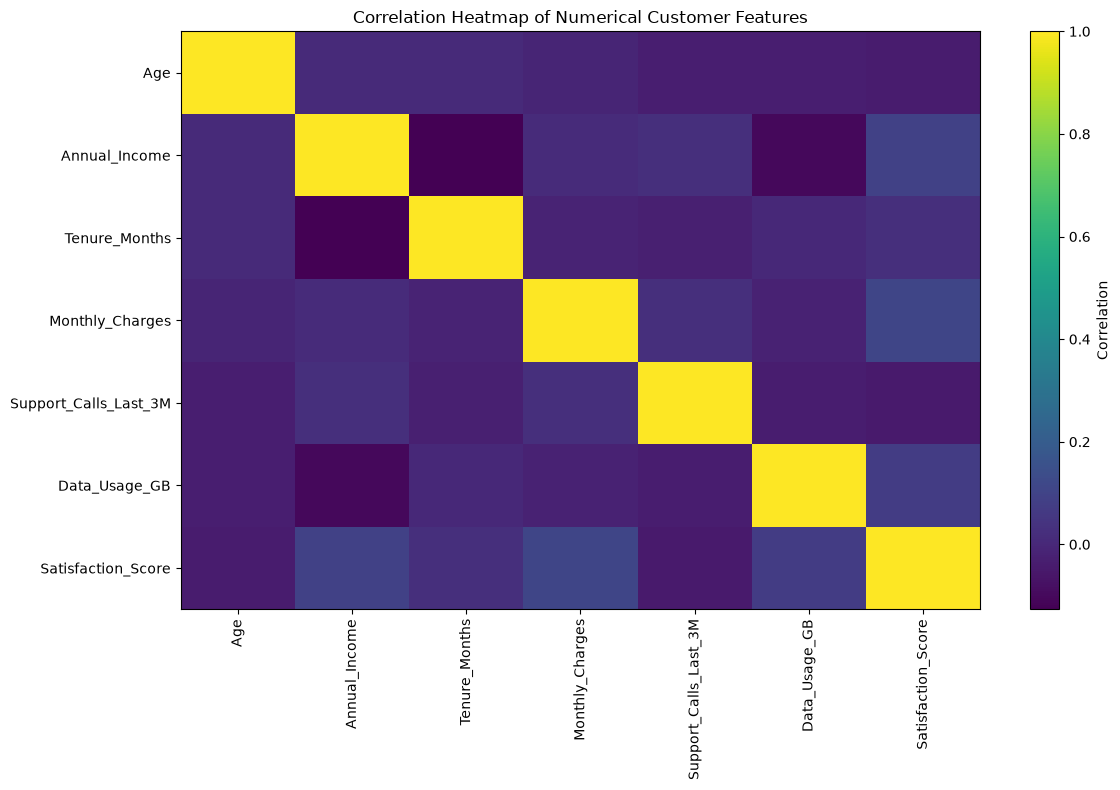

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Age,1.00,0.01,0.01,-0.01,-0.03,-0.03,-0.04
Annual_Income,0.01,1.00,-0.13,0.01,0.02,-0.10,0.09
Tenure_Months,0.01,-0.13,1.00,-0.01,-0.03,0.00,0.03
Monthly_Charges,-0.01,0.01,-0.01,1.00,0.02,-0.02,0.11
Support_Calls_Last_3M,-0.03,0.02,-0.03,0.02,1.00,-0.03,-0.05
Data_Usage_GB,-0.03,-0.10,0.00,-0.02,-0.03,1.00,0.07
Satisfaction_Score,-0.04,0.09,0.03,0.11,-0.05,0.07,1.00


In [7]:
numerical_df = df.select_dtypes(include=np.number)

if numerical_df.shape[1] >= 2:
    correlation_matrix = numerical_df.corr()

    plt.figure(figsize=(12, 8))
    plt.imshow(correlation_matrix, aspect="auto")
    plt.colorbar(label="Correlation")

    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=90
    )
    plt.yticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns
    )

    plt.title("Correlation Heatmap of Numerical Customer Features")
    plt.tight_layout()
    plt.show()

    display(correlation_matrix.round(2))
else:
    print("Not enough numerical columns for a correlation heatmap.")

# 8. Exploratory Data Analysis – Box Plots

Box plots help identify the distribution of numerical features and possible extreme values.

Numerical columns:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']


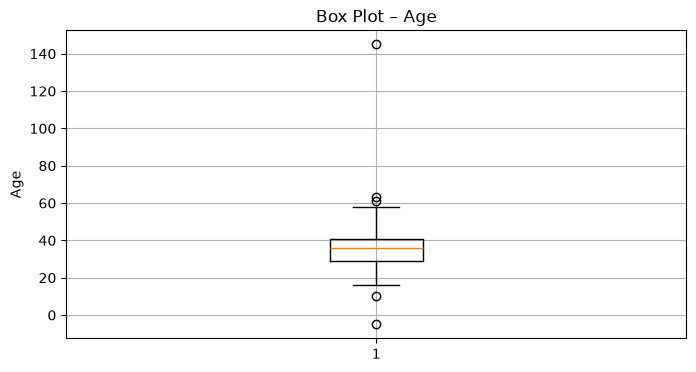

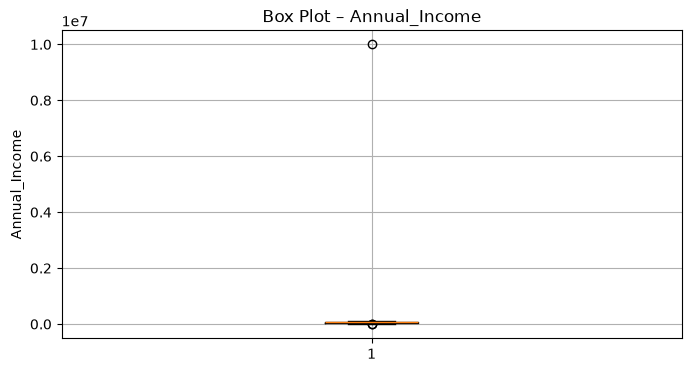

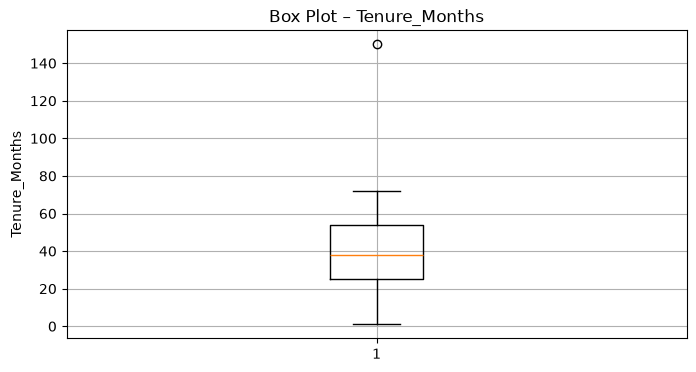

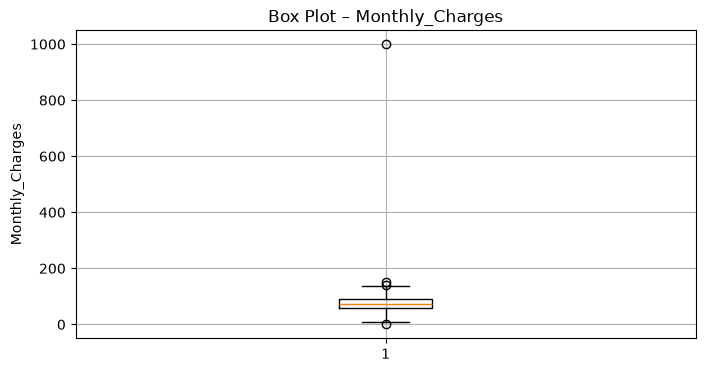

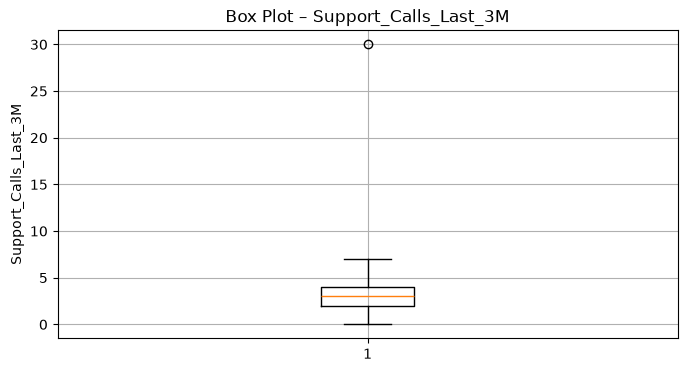

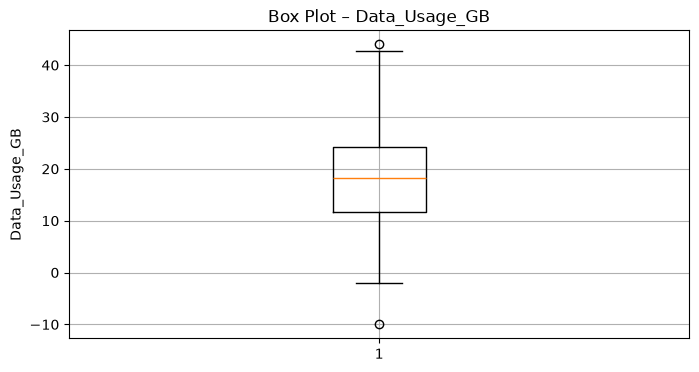

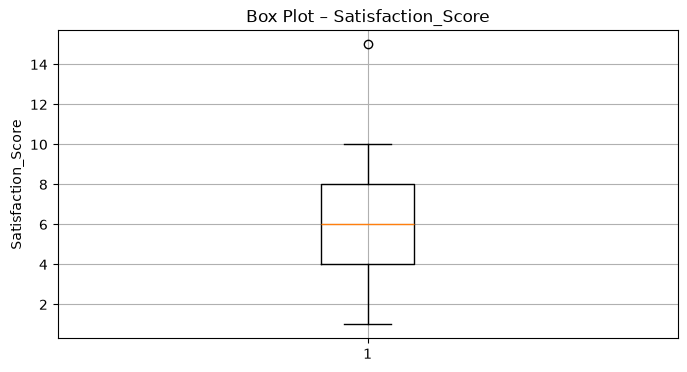

In [8]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna())
    plt.title(f"Box Plot – {column}")
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

# 9. Outlier Detection Using IQR

For every numerical feature:

- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

In [9]:
outlier_summary = []

for column in numerical_columns:
    series = df[column].dropna()

    if len(series) == 0:
        continue

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": int(outlier_mask.sum())
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary.round(2))

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,29.00,41.00,12.00,11.0,59.00,5
1,Annual_Income,49000.00,78200.00,29200.00,5200.0,122000.00,3
2,Tenure_Months,25.00,54.00,29.00,-18.5,97.50,1
3,Monthly_Charges,57.46,90.03,32.57,8.6,138.89,4
4,Support_Calls_Last_3M,2.00,4.00,2.00,-1.0,7.00,1
5,Data_Usage_GB,11.60,24.20,12.60,-7.3,43.10,2
6,Satisfaction_Score,4.00,8.00,4.00,-2.0,14.00,1


# 10. EDA Summary

The EDA stage is now complete.

For **K-Means** and **Hierarchical Clustering**, extreme numerical values are capped using IQR boundaries so that a few extreme observations do not dominate distance-based clustering.

For **DBSCAN**, the original extreme observations are retained because identifying unusual customers is part of the problem itself. DBSCAN can label low-density observations as noise (`-1`).

# ============================================================
# 11. K-MEANS CLUSTERING
# ============================================================

## Problem Statement
**Can we divide customers into groups based on their usage patterns?**

### K-Means Workflow
Raw/cleaned data → Remove unnecessary columns → Feature selection → Encoding → Scaling → Final validation → Elbow Method → Silhouette Score → Select K → Train K-Means → Cluster sizes → Cluster profiling → PCA visualization → Conclusion

## 11.1 Prepare Data for K-Means

K-Means is distance-based, so numerical outliers are capped before scaling.

In [10]:
df_kmeans = df.copy()

# IQR capping for numerical features
for column in numerical_columns:
    if df_kmeans[column].notna().sum() > 0:
        Q1 = df_kmeans[column].quantile(0.25)
        Q3 = df_kmeans[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_kmeans[column] = df_kmeans[column].clip(
            lower=lower_bound,
            upper=upper_bound
        )

print("K-Means data prepared using IQR capping.")
print("Shape:", df_kmeans.shape)

K-Means data prepared using IQR capping.
Shape: (180, 13)


## 11.2 Remove Unnecessary Columns

In [11]:
columns_to_drop = []

if "Customer_ID" in df_kmeans.columns:
    columns_to_drop.append("Customer_ID")

if "Churn" in df_kmeans.columns:
    columns_to_drop.append("Churn")

df_kmeans_model = df_kmeans.drop(
    columns=columns_to_drop,
    errors="ignore"
).copy()

print("Removed columns:", columns_to_drop)
print("Shape:", df_kmeans_model.shape)

Removed columns: ['Customer_ID', 'Churn']
Shape: (180, 11)


## 11.3 Identify Numerical and Categorical Features

In [12]:
numerical_features_k = df_kmeans_model.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_k = df_kmeans_model.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features_k)

print("\nCategorical features:")
print(categorical_features_k)

Numerical features:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical features:
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']


## 11.4 Handle Missing Values

In [13]:
for column in numerical_features_k:
    df_kmeans_model[column] = df_kmeans_model[column].fillna(
        df_kmeans_model[column].median()
    )

for column in categorical_features_k:
    mode_value = df_kmeans_model[column].mode(dropna=True)

    if not mode_value.empty:
        df_kmeans_model[column] = df_kmeans_model[column].fillna(
            mode_value.iloc[0]
        )
    else:
        df_kmeans_model[column] = df_kmeans_model[column].fillna(
            "Unknown"
        )

print(
    "Total missing values after handling:",
    int(df_kmeans_model.isnull().sum().sum())
)

Total missing values after handling: 0


## 11.5 Feature Selection

The selected features describe customer usage and customer characteristics.

In [14]:
preferred_usage_features = [
    "Monthly_Charges",
    "Data_Usage_GB",
    "Support_Calls_Last_3M",
    "Tenure_Months",
    "Age",
    "Satisfaction_Score",
    "Annual_Income"
]

selected_features_k = [
    feature
    for feature in preferred_usage_features
    if feature in df_kmeans_model.columns
]

if not selected_features_k:
    selected_features_k = numerical_features_k.copy()

print("Selected numerical features:")
print(selected_features_k)

Selected numerical features:
['Monthly_Charges', 'Data_Usage_GB', 'Support_Calls_Last_3M', 'Tenure_Months', 'Age', 'Satisfaction_Score', 'Annual_Income']


## 11.6 Prepare Data for Encoding

In [15]:
model_input_k = df_kmeans_model[
    selected_features_k + categorical_features_k
].copy()

print("Shape before encoding:", model_input_k.shape)

Shape before encoding: (180, 11)


## 11.7 Encode Categorical Features

In [16]:
X_kmeans_df = pd.get_dummies(
    model_input_k,
    columns=categorical_features_k,
    drop_first=True,
    dtype=int
)

X_kmeans_df = X_kmeans_df.replace(
    [np.inf, -np.inf],
    np.nan
)

for column in X_kmeans_df.columns:
    if X_kmeans_df[column].isnull().any():
        median_value = X_kmeans_df[column].median()
        X_kmeans_df[column] = X_kmeans_df[column].fillna(
            0 if pd.isna(median_value) else median_value
        )

print("Shape after encoding:", X_kmeans_df.shape)
print(
    "Remaining categorical columns:",
    X_kmeans_df.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()
)

Shape after encoding: (180, 34)
Remaining categorical columns: []


## 11.8 Feature Scaling

In [17]:
scaler_kmeans = StandardScaler()

X_kmeans = scaler_kmeans.fit_transform(X_kmeans_df)

print("Feature scaling completed.")
print("Scaled data shape:", X_kmeans.shape)

Feature scaling completed.
Scaled data shape: (180, 34)


## 11.9 Final Data Validation

In [18]:
print("Shape:", X_kmeans.shape)
print("Total missing values:", int(np.isnan(X_kmeans).sum()))
print("Total infinite values:", int(np.isinf(X_kmeans).sum()))
print("Number of features:", X_kmeans.shape[1])

Shape: (180, 34)
Total missing values: 0
Total infinite values: 0
Number of features: 34


## 11.10 Elbow Method

The Elbow Method is used to understand how inertia changes as the number of clusters increases.

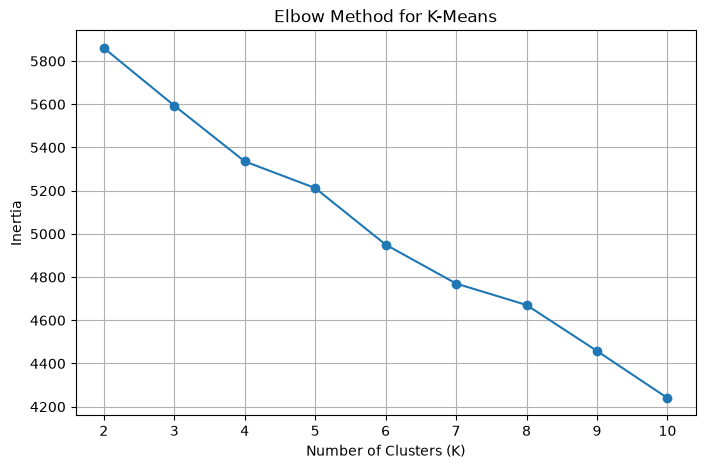

In [19]:
K_range = range(2, 11)
inertia_values = []

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_kmeans)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

## 11.11 Silhouette Score for Different K Values

K = 2, Silhouette Score = 0.0562
K = 3, Silhouette Score = 0.0713
K = 4, Silhouette Score = 0.0818
K = 5, Silhouette Score = 0.0521
K = 6, Silhouette Score = 0.0830
K = 7, Silhouette Score = 0.0923
K = 8, Silhouette Score = 0.0480
K = 9, Silhouette Score = 0.0893
K = 10, Silhouette Score = 0.0714


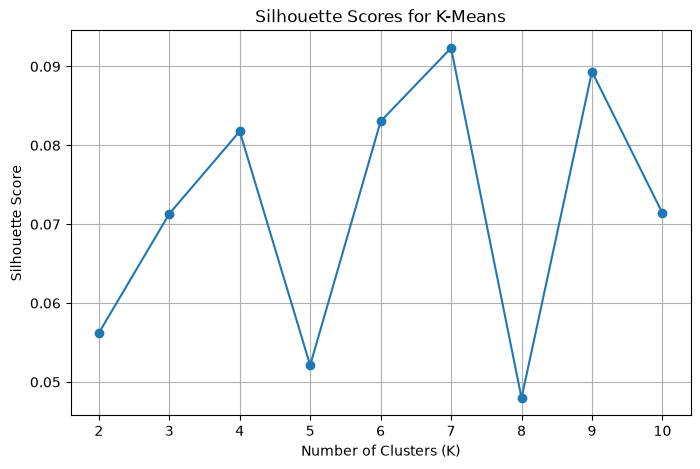

In [20]:
silhouette_scores_k = []

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_kmeans)

    score = silhouette_score(
        X_kmeans,
        labels
    )

    silhouette_scores_k.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(
    list(K_range),
    silhouette_scores_k,
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

## 11.12 Select the Final K

The existing K-Means notebook uses **K = 4** as the practical segmentation choice after considering the Elbow Method and Silhouette Scores.

In [21]:
best_k = 4

if best_k not in K_range:
    raise ValueError("Selected K must be within the tested K range.")

selected_k_score = silhouette_scores_k[
    list(K_range).index(best_k)
]

print("Selected K:", best_k)
print(
    "Silhouette Score for selected K:",
    round(selected_k_score, 4)
)

Selected K: 4
Silhouette Score for selected K: 0.0818


## 11.13 Train the Final K-Means Model

In [22]:
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_kmeans)

print("Final K-Means model trained successfully.")

Final K-Means model trained successfully.


## 11.14 Add Cluster Labels and Count Customers

Customers in each K-Means cluster:
Cluster
0    44
1    41
2    47
3    48
Name: count, dtype: int64


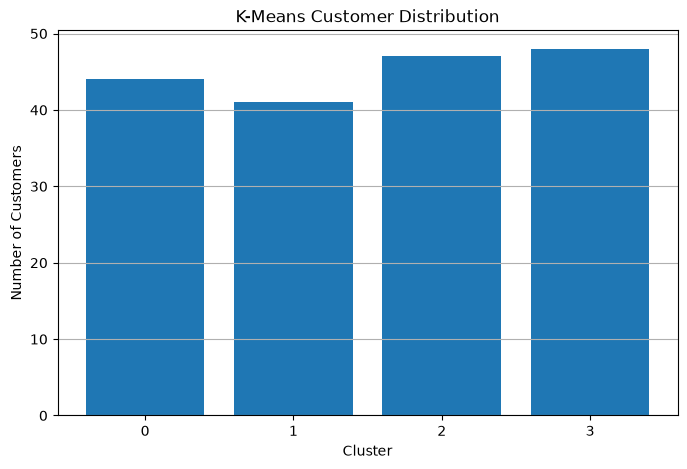

In [23]:
df_kmeans_clustered = df_kmeans_model.copy()
df_kmeans_clustered["Cluster"] = kmeans_labels

kmeans_cluster_counts = (
    df_kmeans_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

print("Customers in each K-Means cluster:")
print(kmeans_cluster_counts)

plt.figure(figsize=(8, 5))
plt.bar(
    kmeans_cluster_counts.index.astype(str),
    kmeans_cluster_counts.values
)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("K-Means Customer Distribution")
plt.grid(axis="y")
plt.show()

## 11.15 Final K-Means Evaluation

In [24]:
kmeans_final_silhouette = silhouette_score(
    X_kmeans,
    kmeans_labels
)

kmeans_final_inertia = kmeans_final.inertia_

print("Final Silhouette Score:", round(kmeans_final_silhouette, 4))
print("Final Inertia:", round(kmeans_final_inertia, 4))

Final Silhouette Score: 0.0818
Final Inertia: 5335.6441


## 11.16 K-Means Cluster Profiling

The profile focuses on the main service-usage variables.

In [25]:
usage_features = [
    "Monthly_Charges",
    "Data_Usage_GB",
    "Support_Calls_Last_3M",
    "Tenure_Months"
]

available_usage_features_k = [
    feature
    for feature in usage_features
    if feature in df_kmeans_clustered.columns
]

kmeans_usage_profile = (
    df_kmeans_clustered[
        available_usage_features_k + ["Cluster"]
    ]
    .groupby("Cluster")
    .mean(numeric_only=True)
)

display(kmeans_usage_profile.round(2))

kmeans_cluster_summary = pd.DataFrame({
    "Customer_Count": kmeans_cluster_counts
})

kmeans_cluster_summary["Percentage"] = (
    kmeans_cluster_summary["Customer_Count"]
    / len(df_kmeans_clustered)
    * 100
)

display(kmeans_cluster_summary.round(2))

,Monthly_Charges,Data_Usage_GB,Support_Calls_Last_3M,Tenure_Months
Cluster,,,,
0,73.83,18.35,3.20,35.91
1,77.89,17.75,3.12,45.68
2,74.61,16.23,3.06,37.67
3,73.41,18.98,2.94,37.27


,Customer_Count,Percentage
Cluster,,
0,44,24.44
1,41,22.78
2,47,26.11
3,48,26.67


## 11.17 PCA Visualization for K-Means

PCA is used only to visualize the high-dimensional clustering result in two dimensions.

Total explained variance: 0.1146


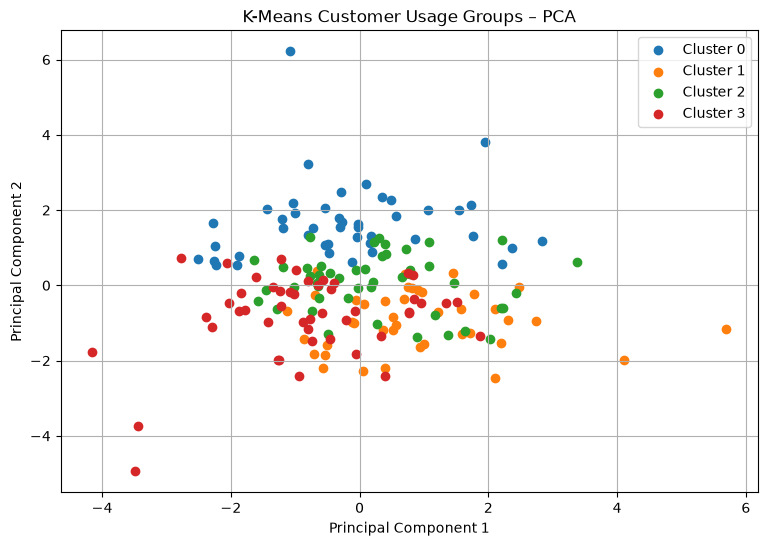

In [26]:
pca_k = PCA(n_components=2)

X_kmeans_pca = pca_k.fit_transform(X_kmeans)

pca_k_df = pd.DataFrame(
    X_kmeans_pca,
    columns=["PC1", "PC2"]
)

pca_k_df["Cluster"] = kmeans_labels

print(
    "Total explained variance:",
    round(pca_k.explained_variance_ratio_.sum(), 4)
)

plt.figure(figsize=(9, 6))

for cluster in sorted(pca_k_df["Cluster"].unique()):
    cluster_data = pca_k_df[
        pca_k_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Customer Usage Groups – PCA")
plt.legend()
plt.grid(True)
plt.show()

## 11.18 K-Means Conclusion

K-Means divides customers into a fixed number of groups according to similarity in the selected usage-related features.

The analysis uses the Elbow Method and Silhouette Score to support the cluster-count decision. The final cluster profile shows how the groups differ in variables such as monthly charges, data usage, support calls, and tenure.

**Conclusion:** K-Means can divide the customers into distinct usage-pattern groups without using the `Churn` label.

In [27]:
print("=" * 65)
print("K-MEANS FINAL CONCLUSION")
print("=" * 65)

print(
    f"Customers were divided into {best_k} groups based on "
    "their usage-related characteristics."
)
print(
    f"The final Silhouette Score is {kmeans_final_silhouette:.4f}, "
    "which summarizes the separation and compactness of the clusters."
)
print(
    "The cluster profile can be used to understand how customer "
    "usage patterns differ across the identified groups."
)

K-MEANS FINAL CONCLUSION
Customers were divided into 4 groups based on their usage-related characteristics.
The final Silhouette Score is 0.0818, which summarizes the separation and compactness of the clusters.
The cluster profile can be used to understand how customer usage patterns differ across the identified groups.


# ============================================================
# 12. HIERARCHICAL CLUSTERING
# ============================================================

## Problem Statement
**Can we discover how customers are related based on their usage patterns?**

### Hierarchical Workflow
Raw/cleaned data → Remove unnecessary columns → Feature selection → Encoding → Scaling → Linkage → Dendrogram → Test cluster counts → Silhouette Score → Final model → Cluster profiling → PCA visualization → Conclusion

## 12.1 Prepare Data for Hierarchical Clustering

Extreme numerical values are capped using IQR boundaries to reduce their influence on distance calculations.

In [28]:
df_hier = df.copy()

for column in numerical_columns:
    if df_hier[column].notna().sum() > 0:
        Q1 = df_hier[column].quantile(0.25)
        Q3 = df_hier[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_hier[column] = df_hier[column].clip(
            lower=lower_bound,
            upper=upper_bound
        )

print("Hierarchical clustering data prepared using IQR capping.")
print("Shape:", df_hier.shape)

Hierarchical clustering data prepared using IQR capping.
Shape: (180, 13)


## 12.2 Remove Unnecessary Columns

In [29]:
columns_to_drop_h = []

if "Customer_ID" in df_hier.columns:
    columns_to_drop_h.append("Customer_ID")

if "Churn" in df_hier.columns:
    columns_to_drop_h.append("Churn")

df_hier_model = df_hier.drop(
    columns=columns_to_drop_h,
    errors="ignore"
).copy()

print("Removed columns:", columns_to_drop_h)
print("Shape:", df_hier_model.shape)

Removed columns: ['Customer_ID', 'Churn']
Shape: (180, 11)


## 12.3 Identify Features and Handle Missing Values

In [30]:
numerical_features_h = df_hier_model.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_h = df_hier_model.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

for column in numerical_features_h:
    df_hier_model[column] = df_hier_model[column].fillna(
        df_hier_model[column].median()
    )

for column in categorical_features_h:
    mode_value = df_hier_model[column].mode(dropna=True)

    if not mode_value.empty:
        df_hier_model[column] = df_hier_model[column].fillna(
            mode_value.iloc[0]
        )
    else:
        df_hier_model[column] = df_hier_model[column].fillna(
            "Unknown"
        )

print("Numerical features:")
print(numerical_features_h)

print("\nCategorical features:")
print(categorical_features_h)

print(
    "\nTotal missing values after handling:",
    int(df_hier_model.isnull().sum().sum())
)

Numerical features:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical features:
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

Total missing values after handling: 0


## 12.4 Feature Selection

In [31]:
selected_features_h = [
    feature
    for feature in preferred_usage_features
    if feature in df_hier_model.columns
]

if not selected_features_h:
    selected_features_h = numerical_features_h.copy()

print("Selected numerical features:")
print(selected_features_h)

Selected numerical features:
['Monthly_Charges', 'Data_Usage_GB', 'Support_Calls_Last_3M', 'Tenure_Months', 'Age', 'Satisfaction_Score', 'Annual_Income']


## 12.5 Encoding

In [32]:
model_input_h = df_hier_model[
    selected_features_h + categorical_features_h
].copy()

X_hier_df = pd.get_dummies(
    model_input_h,
    columns=categorical_features_h,
    drop_first=True,
    dtype=int
)

X_hier_df = X_hier_df.replace(
    [np.inf, -np.inf],
    np.nan
)

for column in X_hier_df.columns:
    if X_hier_df[column].isnull().any():
        median_value = X_hier_df[column].median()
        X_hier_df[column] = X_hier_df[column].fillna(
            0 if pd.isna(median_value) else median_value
        )

print("Shape before encoding:", model_input_h.shape)
print("Shape after encoding:", X_hier_df.shape)

Shape before encoding: (180, 11)
Shape after encoding: (180, 34)


## 12.6 Feature Scaling and Final Validation

In [33]:
scaler_hier = StandardScaler()

X_hier = scaler_hier.fit_transform(X_hier_df)

print("Feature scaling completed.")
print("Shape:", X_hier.shape)
print("Total missing values:", int(np.isnan(X_hier).sum()))
print("Total infinite values:", int(np.isinf(X_hier).sum()))

Feature scaling completed.
Shape: (180, 34)
Total missing values: 0
Total infinite values: 0


## 12.7 Create the Hierarchical Linkage Matrix

Ward linkage is used to build the customer hierarchy.

In [34]:
linkage_matrix = linkage(
    X_hier,
    method="ward"
)

print("Linkage matrix created successfully.")
print("Linkage matrix shape:", linkage_matrix.shape)

Linkage matrix created successfully.
Linkage matrix shape: (179, 4)


## 12.8 Dendrogram

The dendrogram shows how customer groups merge as the linkage distance increases.

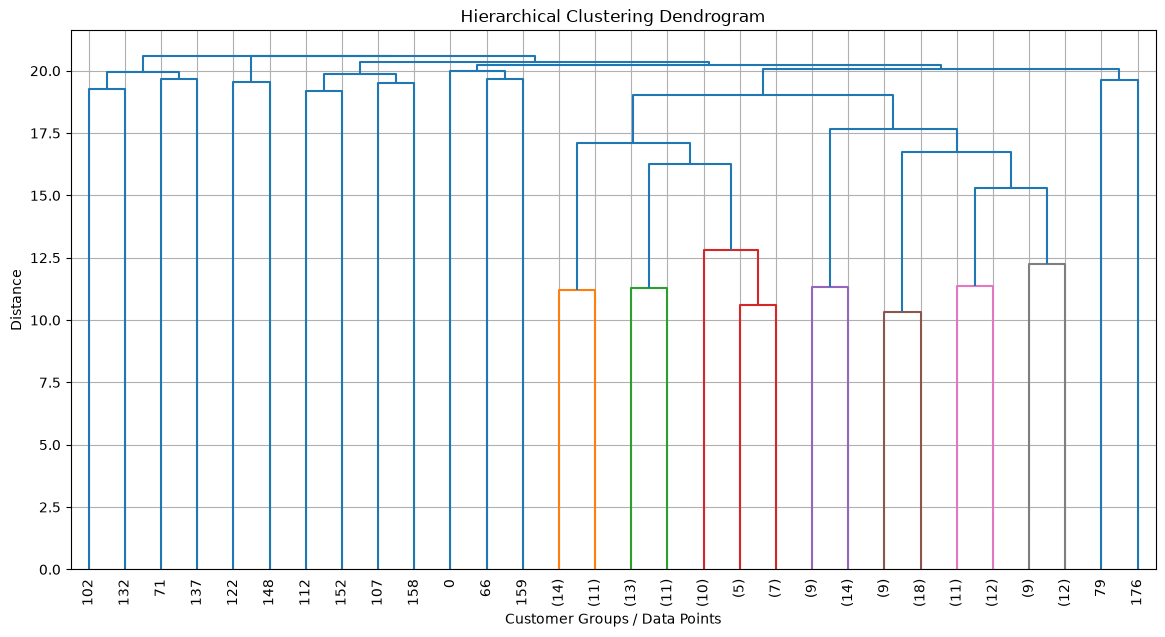

In [35]:
plt.figure(figsize=(14, 7))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Groups / Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

## 12.9 Test Different Numbers of Clusters

Silhouette Score is used to compare possible cluster counts.

Clusters = 2, Silhouette Score = 0.5119
Clusters = 3, Silhouette Score = 0.5097
Clusters = 4, Silhouette Score = 0.5066
Clusters = 5, Silhouette Score = 0.5072
Clusters = 6, Silhouette Score = 0.5067
Clusters = 7, Silhouette Score = 0.5074
Clusters = 8, Silhouette Score = 0.5065


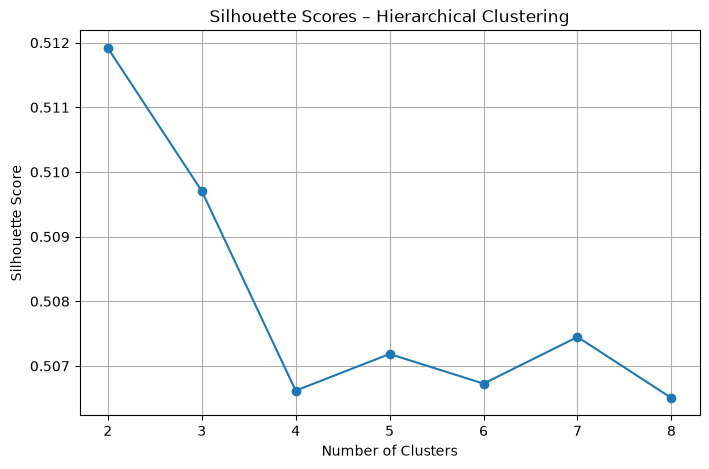

In [36]:
cluster_range_h = range(2, 9)
silhouette_scores_h = []

for n_clusters in cluster_range_h:
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage="ward"
    )

    labels = model.fit_predict(X_hier)

    score = silhouette_score(
        X_hier,
        labels
    )

    silhouette_scores_h.append(score)

    print(
        f"Clusters = {n_clusters}, "
        f"Silhouette Score = {score:.4f}"
    )

plt.figure(figsize=(8, 5))
plt.plot(
    list(cluster_range_h),
    silhouette_scores_h,
    marker="o"
)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores – Hierarchical Clustering")
plt.xticks(list(cluster_range_h))
plt.grid(True)
plt.show()

## 12.10 Select the Number of Clusters

The cluster count with the highest tested Silhouette Score is selected.

In [37]:
best_h_index = int(np.argmax(silhouette_scores_h))

best_n_clusters_h = list(cluster_range_h)[best_h_index]
best_h_silhouette = silhouette_scores_h[best_h_index]

print("Selected number of clusters:", best_n_clusters_h)
print("Best Silhouette Score:", round(best_h_silhouette, 4))

Selected number of clusters: 2
Best Silhouette Score: 0.5119


## 12.11 Train the Final Hierarchical Clustering Model

In [38]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=best_n_clusters_h,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_hier)

print(
    "Final Hierarchical Clustering model trained successfully."
)

Final Hierarchical Clustering model trained successfully.


## 12.12 Cluster Sizes and Evaluation

Customers in each cluster:
Cluster
0    176
1      4
Name: count, dtype: int64

Final Silhouette Score: 0.5119


,Customer_Count,Percentage
Cluster,,
0,176,97.78
1,4,2.22


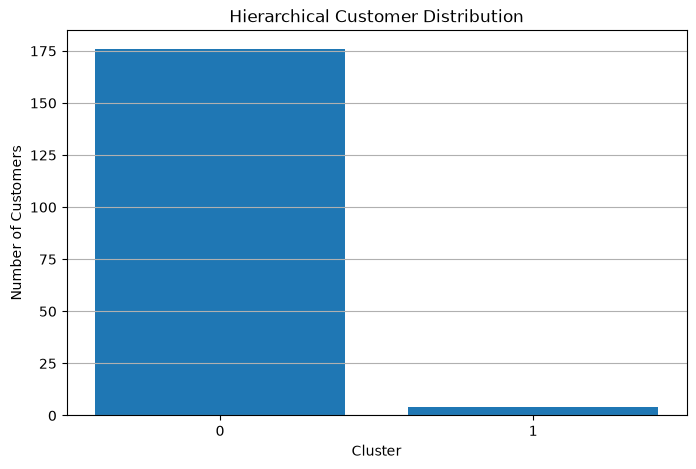

In [39]:
df_hier_clustered = df_hier_model.copy()
df_hier_clustered["Cluster"] = hierarchical_labels

hier_cluster_counts = (
    df_hier_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

hier_final_silhouette = silhouette_score(
    X_hier,
    hierarchical_labels
)

print("Customers in each cluster:")
print(hier_cluster_counts)

print(
    "\nFinal Silhouette Score:",
    round(hier_final_silhouette, 4)
)

hier_cluster_summary = pd.DataFrame({
    "Customer_Count": hier_cluster_counts
})

hier_cluster_summary["Percentage"] = (
    hier_cluster_summary["Customer_Count"]
    / len(df_hier_clustered)
    * 100
)

display(hier_cluster_summary.round(2))

plt.figure(figsize=(8, 5))
plt.bar(
    hier_cluster_counts.index.astype(str),
    hier_cluster_counts.values
)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Hierarchical Customer Distribution")
plt.grid(axis="y")
plt.show()

## 12.13 Hierarchical Cluster Profiling

In [40]:
available_usage_features_h = [
    feature
    for feature in usage_features
    if feature in df_hier_clustered.columns
]

hier_usage_profile = (
    df_hier_clustered[
        available_usage_features_h + ["Cluster"]
    ]
    .groupby("Cluster")
    .mean(numeric_only=True)
)

display(hier_usage_profile.round(2))

,Monthly_Charges,Data_Usage_GB,Support_Calls_Last_3M,Tenure_Months
Cluster,,,,
0,74.82,17.87,3.10,39.02
1,75.88,15.88,2.25,36.25


## 12.14 PCA Visualization

Total explained variance: 0.1146


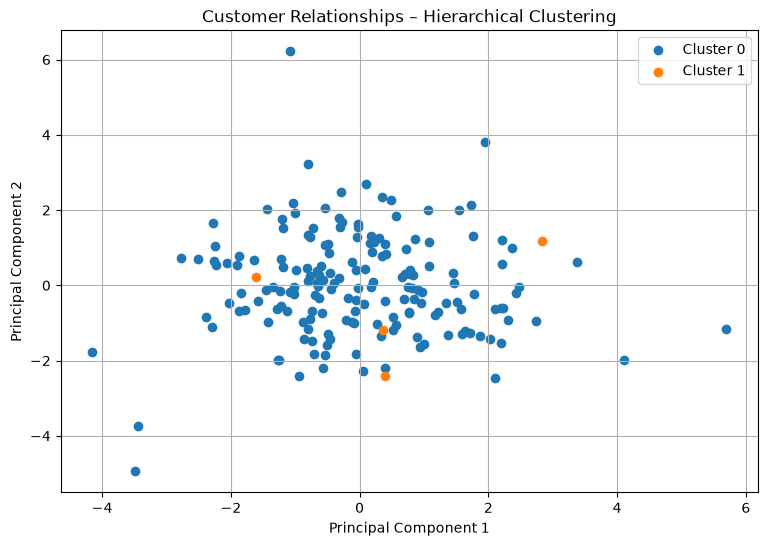

In [41]:
pca_h = PCA(n_components=2)

X_hier_pca = pca_h.fit_transform(X_hier)

pca_h_df = pd.DataFrame(
    X_hier_pca,
    columns=["PC1", "PC2"]
)

pca_h_df["Cluster"] = hierarchical_labels

print(
    "Total explained variance:",
    round(pca_h.explained_variance_ratio_.sum(), 4)
)

plt.figure(figsize=(9, 6))

for cluster in sorted(pca_h_df["Cluster"].unique()):
    cluster_data = pca_h_df[
        pca_h_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Relationships – Hierarchical Clustering")
plt.legend()
plt.grid(True)
plt.show()

## 12.15 Hierarchical Clustering Conclusion

Hierarchical Clustering builds a hierarchy of customers according to their similarity in usage-related features.

The dendrogram shows how customers are progressively grouped, while the Silhouette Score helps select a useful number of final clusters. Cluster profiling then describes the usage characteristics of each relationship group.

**Conclusion:** Hierarchical Clustering can discover groups of customers that are related through similar service-usage patterns, without using the `Churn` label.

In [42]:
print("=" * 65)
print("HIERARCHICAL CLUSTERING FINAL CONCLUSION")
print("=" * 65)

print(
    f"Hierarchical Clustering identified {best_n_clusters_h} "
    "customer groups based on usage-related similarity."
)
print(
    f"The final Silhouette Score is {hier_final_silhouette:.4f}."
)
print(
    "The dendrogram and cluster profiles help explain how "
    "customers are related to one another through their usage patterns."
)

HIERARCHICAL CLUSTERING FINAL CONCLUSION
Hierarchical Clustering identified 2 customer groups based on usage-related similarity.
The final Silhouette Score is 0.5119.
The dendrogram and cluster profiles help explain how customers are related to one another through their usage patterns.


# ============================================================
# 13. DBSCAN CLUSTERING
# ============================================================

## Problem Statement
**Can we identify unusual customers based on their service usage?**

### DBSCAN Workflow
Raw/cleaned data → Keep extreme observations → Remove unnecessary columns → Feature selection → Encoding → Scaling → Final validation → Choose `min_samples` → K-distance plot → Select `eps` → Train DBSCAN → Identify noise/unusual customers → Evaluate → Profile → PCA visualization → Conclusion

## 13.1 Prepare Data for DBSCAN

Unlike K-Means and Hierarchical Clustering, DBSCAN is specifically useful for detecting low-density observations.

Therefore, **outliers identified during EDA are not deleted or capped here**. They are retained so that DBSCAN has the opportunity to classify unusual observations as noise.

In [43]:
df_dbscan = df.copy()

print("All customer records are retained for DBSCAN.")
print("Rows available:", len(df_dbscan))

All customer records are retained for DBSCAN.
Rows available: 180


## 13.2 Remove Unnecessary Columns

In [44]:
columns_to_drop_d = []

if "Customer_ID" in df_dbscan.columns:
    columns_to_drop_d.append("Customer_ID")

if "Churn" in df_dbscan.columns:
    columns_to_drop_d.append("Churn")

df_dbscan_model = df_dbscan.drop(
    columns=columns_to_drop_d,
    errors="ignore"
).copy()

print("Removed columns:", columns_to_drop_d)
print("Shape:", df_dbscan_model.shape)

Removed columns: ['Customer_ID', 'Churn']
Shape: (180, 11)


## 13.3 Identify Features and Handle Missing Values

In [45]:
numerical_features_d = df_dbscan_model.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_d = df_dbscan_model.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

for column in numerical_features_d:
    df_dbscan_model[column] = df_dbscan_model[column].fillna(
        df_dbscan_model[column].median()
    )

for column in categorical_features_d:
    mode_value = df_dbscan_model[column].mode(dropna=True)

    if not mode_value.empty:
        df_dbscan_model[column] = df_dbscan_model[column].fillna(
            mode_value.iloc[0]
        )
    else:
        df_dbscan_model[column] = df_dbscan_model[column].fillna(
            "Unknown"
        )

print("Numerical features:")
print(numerical_features_d)

print("\nCategorical features:")
print(categorical_features_d)

print(
    "\nTotal missing values after handling:",
    int(df_dbscan_model.isnull().sum().sum())
)

Numerical features:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical features:
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']

Total missing values after handling: 0


## 13.4 Feature Selection

In [46]:
selected_features_d = [
    feature
    for feature in preferred_usage_features
    if feature in df_dbscan_model.columns
]

if not selected_features_d:
    selected_features_d = numerical_features_d.copy()

print("Selected numerical features:")
print(selected_features_d)

Selected numerical features:
['Monthly_Charges', 'Data_Usage_GB', 'Support_Calls_Last_3M', 'Tenure_Months', 'Age', 'Satisfaction_Score', 'Annual_Income']


## 13.5 Encoding

In [47]:
model_input_d = df_dbscan_model[
    selected_features_d + categorical_features_d
].copy()

X_dbscan_df = pd.get_dummies(
    model_input_d,
    columns=categorical_features_d,
    drop_first=True,
    dtype=int
)

X_dbscan_df = X_dbscan_df.replace(
    [np.inf, -np.inf],
    np.nan
)

for column in X_dbscan_df.columns:
    if X_dbscan_df[column].isnull().any():
        median_value = X_dbscan_df[column].median()
        X_dbscan_df[column] = X_dbscan_df[column].fillna(
            0 if pd.isna(median_value) else median_value
        )

print("Shape before encoding:", model_input_d.shape)
print("Shape after encoding:", X_dbscan_df.shape)

Shape before encoding: (180, 11)
Shape after encoding: (180, 34)


## 13.6 Feature Scaling

In [48]:
scaler_dbscan = StandardScaler()

X_dbscan = scaler_dbscan.fit_transform(X_dbscan_df)

print("Feature scaling completed.")
print("Scaled data shape:", X_dbscan.shape)

Feature scaling completed.
Scaled data shape: (180, 34)


## 13.7 Final Data Validation

In [49]:
print("Shape:", X_dbscan.shape)
print("Total missing values:", int(np.isnan(X_dbscan).sum()))
print("Total infinite values:", int(np.isinf(X_dbscan).sum()))
print("Number of features:", X_dbscan.shape[1])

Shape: (180, 34)
Total missing values: 0
Total infinite values: 0
Number of features: 34


## 13.8 Choose `min_samples`

A safe value is selected based on the dataset size.

In [50]:
n_samples_d = X_dbscan.shape[0]

if n_samples_d < 3:
    raise ValueError(
        "DBSCAN requires at least 3 customer records."
    )

min_samples_d = max(
    5,
    min(10, n_samples_d - 1)
)

print("Selected min_samples:", min_samples_d)

Selected min_samples: 10


## 13.9 K-Distance Plot for Selecting `eps`

The distance to the kth nearest neighbor helps identify a reasonable `eps` value.

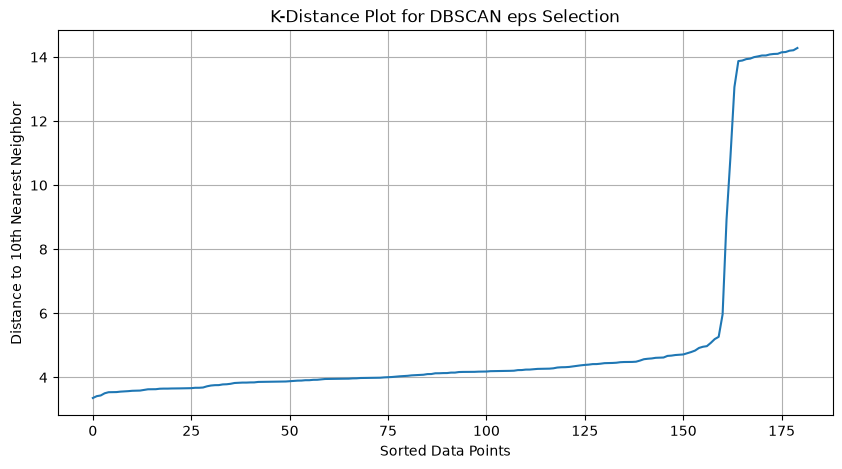

In [51]:
neighbors_d = NearestNeighbors(
    n_neighbors=min_samples_d
)

neighbors_d.fit(X_dbscan)

distances_d, indices_d = neighbors_d.kneighbors(
    X_dbscan
)

k_distances_d = np.sort(
    distances_d[:, min_samples_d - 1]
)

plt.figure(figsize=(10, 5))
plt.plot(k_distances_d)

plt.xlabel("Sorted Data Points")
plt.ylabel(
    f"Distance to {min_samples_d}th Nearest Neighbor"
)
plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.grid(True)
plt.show()

## 13.10 Select an Initial `eps`

A high percentile of the k-distance values is used as a reproducible initial value. The k-distance plot can also be inspected visually.

In [52]:
eps_d = float(np.percentile(k_distances_d, 90))

print("Selected eps:", round(eps_d, 4))
print("Selected min_samples:", min_samples_d)

Selected eps: 9.122
Selected min_samples: 10


## 13.11 Train the DBSCAN Model

In [53]:
dbscan_model = DBSCAN(
    eps=eps_d,
    min_samples=min_samples_d
)

dbscan_labels = dbscan_model.fit_predict(
    X_dbscan
)

print("DBSCAN model trained successfully.")

DBSCAN model trained successfully.


## 13.12 Identify Clusters and Unusual Customers

DBSCAN uses:
- `0, 1, 2, ...` for regular dense clusters
- `-1` for noise observations

For this problem, noise observations are treated as **potentially unusual customers**.

In [54]:
unique_labels_d = sorted(set(dbscan_labels))

noise_count_d = int(
    np.sum(dbscan_labels == -1)
)

cluster_count_d = len([
    label
    for label in unique_labels_d
    if label != -1
])

noise_percentage_d = (
    noise_count_d / len(dbscan_labels) * 100
)

print("Cluster labels:", unique_labels_d)
print("Number of regular clusters:", cluster_count_d)
print("Number of unusual/noise customers:", noise_count_d)
print(
    "Percentage of unusual/noise customers:",
    round(noise_percentage_d, 2),
    "%"
)

Cluster labels: [np.int64(-1), np.int64(0)]
Number of regular clusters: 1
Number of unusual/noise customers: 18
Percentage of unusual/noise customers: 10.0 %


## 13.13 Cluster Size Summary

,Customer_Count,Percentage
Cluster,,
-1,18,10.0
0,162,90.0


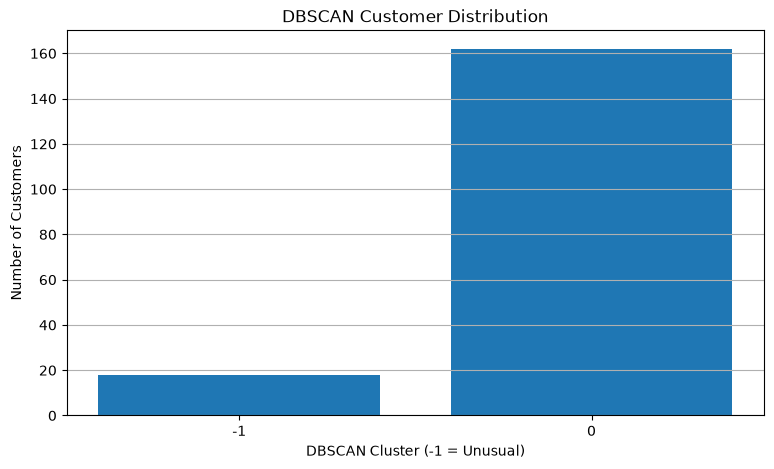

In [55]:
dbscan_cluster_counts = pd.Series(
    dbscan_labels,
    name="Cluster"
).value_counts().sort_index()

dbscan_cluster_summary = dbscan_cluster_counts.to_frame(
    name="Customer_Count"
)

dbscan_cluster_summary["Percentage"] = (
    dbscan_cluster_summary["Customer_Count"]
    / len(dbscan_labels)
    * 100
)

display(dbscan_cluster_summary.round(2))

plt.figure(figsize=(9, 5))
plt.bar(
    dbscan_cluster_summary.index.astype(str),
    dbscan_cluster_summary["Customer_Count"]
)
plt.xlabel("DBSCAN Cluster (-1 = Unusual)")
plt.ylabel("Number of Customers")
plt.title("DBSCAN Customer Distribution")
plt.grid(axis="y")
plt.show()

## 13.14 Add DBSCAN Labels and Identify Unusual Customers

In [56]:
df_dbscan_clustered = df_dbscan_model.copy()

df_dbscan_clustered["DBSCAN_Cluster"] = dbscan_labels

df_dbscan_clustered["Customer_Type"] = np.where(
    df_dbscan_clustered["DBSCAN_Cluster"] == -1,
    "Unusual Customer",
    "Regular Customer"
)

unusual_customers = df_dbscan_clustered[
    df_dbscan_clustered["DBSCAN_Cluster"] == -1
].copy()

print("Number of unusual customers:", len(unusual_customers))

display(
    df_dbscan_clustered[
        ["DBSCAN_Cluster", "Customer_Type"]
    ].head()
)

if len(unusual_customers) > 0:
    print("Sample unusual customers:")
    display(unusual_customers.head(10))
else:
    print("No unusual customers were identified with the selected DBSCAN parameters.")

Number of unusual customers: 18


,DBSCAN_Cluster,Customer_Type
0,-1,Unusual Customer
1,0,Regular Customer
2,0,Regular Customer
3,0,Regular Customer
4,0,Regular Customer


Sample unusual customers:


,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,DBSCAN_Cluster,Customer_Type
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,-1,Unusual Customer
35,33.0,83900.0,42.0,80.50,30.0,19.0,3.0,2 Year,Credit Card,North,Standard,-1,Unusual Customer
66,37.0,56900.0,38.0,67.10,4.0,36.4,1.0,Monthly,Credit Card,North,basic,-1,Unusual Customer
71,44.0,64400.0,17.0,115.14,3.0,8.5,4.0,2 Year,Credit Card,West,premium,-1,Unusual Customer
79,32.0,100000.0,12.0,56.23,3.0,9.8,6.0,1 Year,Debit Card,west,Premium,-1,Unusual Customer
95,37.0,9999999.0,5.0,91.79,4.0,6.4,9.0,1 Year,Bank Transfer,East,Premium,-1,Unusual Customer
102,37.0,62300.0,51.0,65.34,2.0,18.2,2.0,2-Year,Debit Card,West,Standard,-1,Unusual Customer
107,47.0,73900.0,51.0,12.71,1.0,24.2,9.0,Monthly,Bank Transfer,NORTH,Standard,-1,Unusual Customer
112,52.0,75400.0,31.0,55.51,4.0,9.4,9.0,1 year,Bank Transfer,South,Standard,-1,Unusual Customer
122,34.0,36600.0,69.0,104.15,3.0,15.8,3.0,monthly,Debit Card,East,Premium,-1,Unusual Customer


## 13.15 DBSCAN Silhouette Evaluation

The Silhouette Score is calculated only when at least two regular clusters exist. Noise points are excluded from this calculation.

In [57]:
non_noise_mask_d = dbscan_labels != -1

regular_labels_d = dbscan_labels[
    non_noise_mask_d
]

regular_data_d = X_dbscan[
    non_noise_mask_d
]

if (
    len(regular_data_d) > 1
    and len(np.unique(regular_labels_d)) >= 2
):
    dbscan_silhouette = silhouette_score(
        regular_data_d,
        regular_labels_d
    )

    print(
        "DBSCAN Silhouette Score (excluding noise):",
        round(dbscan_silhouette, 4)
    )
else:
    dbscan_silhouette = np.nan

    print(
        "Silhouette Score cannot be calculated because "
        "DBSCAN produced fewer than two regular clusters."
    )

Silhouette Score cannot be calculated because DBSCAN produced fewer than two regular clusters.


## 13.16 DBSCAN Cluster Profiling

In [58]:
available_usage_features_d = [
    feature
    for feature in usage_features
    if feature in df_dbscan_clustered.columns
]

if cluster_count_d > 0:
    dbscan_regular_profile = (
        df_dbscan_clustered[
            df_dbscan_clustered["DBSCAN_Cluster"] != -1
        ][
            available_usage_features_d + ["DBSCAN_Cluster"]
        ]
        .groupby("DBSCAN_Cluster")
        .mean(numeric_only=True)
    )

    display(dbscan_regular_profile.round(2))
else:
    print("No regular DBSCAN clusters were produced.")

if len(unusual_customers) > 0:
    dbscan_unusual_profile = (
        unusual_customers[
            available_usage_features_d
        ]
        .mean(numeric_only=True)
        .to_frame("Average_Value")
    )

    print("Average usage values for unusual customers:")
    display(dbscan_unusual_profile.round(2))

,Monthly_Charges,Data_Usage_GB,Support_Calls_Last_3M,Tenure_Months
DBSCAN_Cluster,,,,
0,75.07,17.88,3.07,39.64


Average usage values for unusual customers:


,Average_Value
Monthly_Charges,120.94
Data_Usage_GB,17.25
Support_Calls_Last_3M,4.39
Tenure_Months,35.78


## 13.17 PCA Visualization

PCA is used only to visualize the DBSCAN results. Noise points (`-1`) are shown separately from regular clusters.

Total explained variance: 0.1127


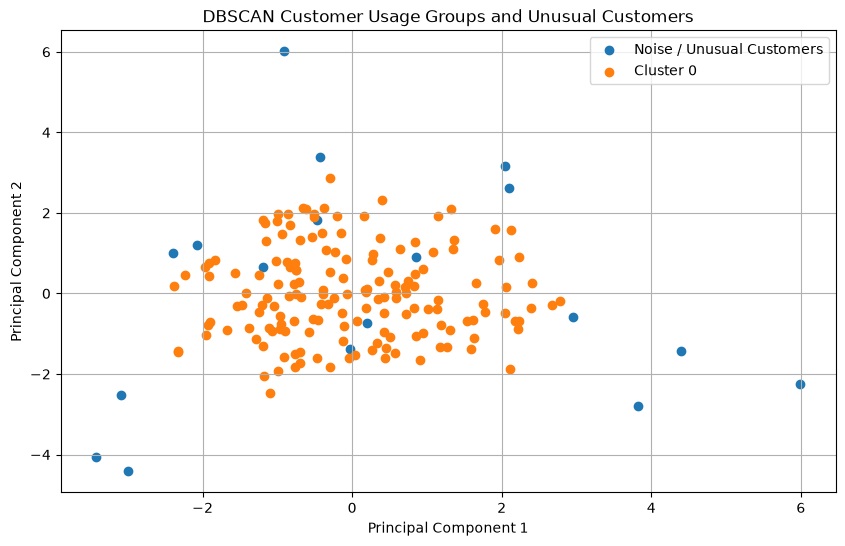

In [59]:
pca_d = PCA(n_components=2)

X_dbscan_pca = pca_d.fit_transform(
    X_dbscan
)

pca_d_df = pd.DataFrame(
    X_dbscan_pca,
    columns=["PC1", "PC2"]
)

pca_d_df["DBSCAN_Cluster"] = dbscan_labels

print(
    "Total explained variance:",
    round(pca_d.explained_variance_ratio_.sum(), 4)
)

plt.figure(figsize=(10, 6))

for cluster in sorted(
    pca_d_df["DBSCAN_Cluster"].unique()
):
    cluster_data = pca_d_df[
        pca_d_df["DBSCAN_Cluster"] == cluster
    ]

    if cluster == -1:
        label = "Noise / Unusual Customers"
    else:
        label = f"Cluster {cluster}"

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=label
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Customer Usage Groups and Unusual Customers")
plt.legend()
plt.grid(True)
plt.show()

## 13.18 DBSCAN Conclusion

DBSCAN groups customers according to the density of their service-usage patterns rather than requiring a fixed number of clusters.

Customers that do not belong to a sufficiently dense region are labelled as noise (`-1`). In this problem, these noise observations are treated as **potentially unusual customers**.

**Conclusion:** DBSCAN can help identify customers whose service-usage patterns are different from the main customer groups, while also discovering dense groups of regular customers.

In [60]:
print("=" * 65)
print("DBSCAN FINAL CONCLUSION")
print("=" * 65)

print(
    f"DBSCAN identified {cluster_count_d} regular customer clusters."
)
print(
    f"It identified {noise_count_d} unusual/noise customers "
    f"({noise_percentage_d:.2f}% of the dataset)."
)

if not pd.isna(dbscan_silhouette):
    print(
        f"The Silhouette Score for regular clusters, excluding noise, "
        f"is {dbscan_silhouette:.4f}."
    )
else:
    print(
        "A Silhouette Score was not available because DBSCAN did not "
        "produce at least two regular clusters."
    )

print(
    "The unusual customers can be investigated further using their "
    "service-usage characteristics."
)

DBSCAN FINAL CONCLUSION
DBSCAN identified 1 regular customer clusters.
It identified 18 unusual/noise customers (10.00% of the dataset).
A Silhouette Score was not available because DBSCAN did not produce at least two regular clusters.
The unusual customers can be investigated further using their service-usage characteristics.


# 14. Final Summary of the Three Models

The three algorithms answer **different questions**, so they should not be treated as interchangeable.

| Model | Problem Statement | Main Purpose |
|---|---|---|
| **K-Means** | Can we divide customers into groups based on their usage patterns? | Divide customers into a fixed number of usage groups |
| **Hierarchical Clustering** | Can we discover how customers are related based on their usage patterns? | Build a hierarchy of customer relationships and form groups |
| **DBSCAN** | Can we identify unusual customers based on their service usage? | Find dense customer groups and identify low-density/noise customers |



# 15. Final Conclusion

This notebook demonstrates three separate unsupervised-learning approaches on the same customer usage dataset.

**K-Means** focuses on dividing customers into a selected number of usage groups.

**Hierarchical Clustering** focuses on discovering relationships and hierarchical groupings among customers.

**DBSCAN** focuses on density-based groups and the identification of potentially unusual customers.

The `Churn` column is not used to create the clusters, so the analysis remains unsupervised.